<a href="https://colab.research.google.com/github/devMoamen/Adult-income-analysis/blob/main/Resampling_Datetime_Data(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#Part 1) Load the data and make a datetime index.

#### Load the data

In [45]:
url="https://docs.google.com/spreadsheets/d/e/2PACX-1vT_jChgNsQbHbg4TGepzIqk8XC9DTIKmyyxb1upo5cfZCgbfIUQc2ZC0YMzuU5uApP140Ob49KBjdqh/pub?gid=1198589591&single=true&output=csv"
df = pd.read_csv(url)

In [46]:
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


#### Convert the date column to datetime dtype

In [47]:
df['datetime'] = pd.to_datetime(df['date'], format='%Y%m%d')
df['datetime'].head()

,datetime
0,1979-01-01
1,1979-01-02
2,1979-01-03
3,1979-01-04
4,1979-01-05


#### Set the date column as the index

In [48]:
df = df.set_index('datetime')
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
datetime,,,,,,,,,,
1979-01-01,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1979-01-02,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
1979-01-03,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
1979-01-04,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
1979-01-05,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


##### Filter out only the required data

In [49]:
#Keep only data from the year 2000 or later.
df_cleaned = df[df.index.year >= 2000]
df_cleaned.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
datetime,,,,,,,,,,
2000-01-01,20000101,7.0,0.4,18.0,10.8,7.0,4.9,0.0,102450.0,0.0
2000-01-02,20000102,7.0,0.7,20.0,11.5,7.9,5.0,0.2,102530.0,0.0
2000-01-03,20000103,8.0,0.0,13.0,9.5,9.4,7.2,6.0,101860.0,0.0
2000-01-04,20000104,5.0,2.9,34.0,11.0,7.0,4.4,0.2,101480.0,0.0
2000-01-05,20000105,5.0,1.3,25.0,10.8,6.4,1.9,0.8,101420.0,0.0


In [50]:
#Keep only the following features: precipitation,mean_temp,min_temp,max_temp,snow_depth
df_cleaned = df_cleaned.drop(columns=['date', 'cloud_cover', 'sunshine', 'global_radiation', 'pressure'])
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7671 entries, 2000-01-01 to 2020-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   max_temp       7281 non-null   float64
 1   mean_temp      7252 non-null   float64
 2   min_temp       7285 non-null   float64
 3   precipitation  7281 non-null   float64
 4   snow_depth     5919 non-null   float64
dtypes: float64(5)
memory usage: 359.6 KB


In [51]:
df_cleaned.isnull().sum()

,0
max_temp,390
mean_temp,419
min_temp,386
precipitation,390
snow_depth,1752


#### Impute any missing values

In [52]:
#Interpolate temperature columns
temp_cols = ['max_temp', 'mean_temp', 'min_temp']
df_cleaned[temp_cols] = df_cleaned[temp_cols].interpolate(method='linear')

#Fill precipitation and snow_depth with 0
df_cleaned['precipitation'] = df_cleaned['precipitation'].fillna(0)
df_cleaned['snow_depth'] = df_cleaned['snow_depth'].fillna(0)

# Check missing values
df_cleaned.isnull().sum()

,0
max_temp,0
mean_temp,0
min_temp,0
precipitation,0
snow_depth,0


#Part 2) Answer the Questions with Visualizations (Using the Correct Frequency)

#### Q1: What month had the most precipitation between 2000 through 2010?

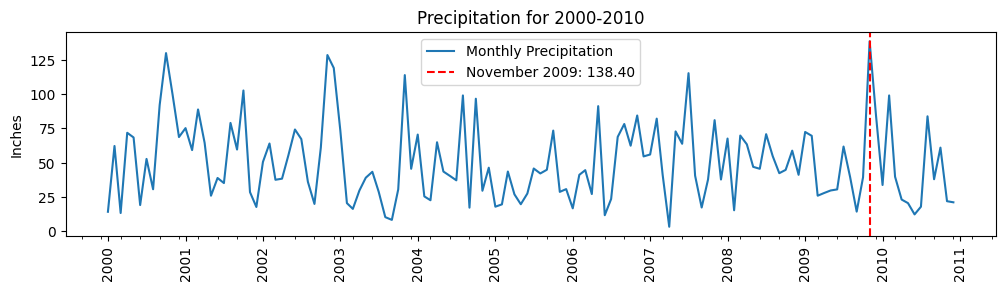

In [53]:
# Resample to monthly sum
monthly_precip = df_cleaned['precipitation'].resample('MS').sum()

# Filter for 2000 through 2010
precip_2000_2010 = monthly_precip.loc['2000':'2010']

# Find the max value and its date
max_val = precip_2000_2010.max()
max_date = precip_2000_2010.idxmax()

# Create a wide figure
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(precip_2000_2010.index, precip_2000_2010.values, label='Monthly Precipitation')

# Add vertical line at max date
label_text = f"{max_date.strftime('%B %Y')}: {max_val:.2f}"
ax.axvline(max_date, color='red', linestyle='--', label=label_text)

# Set Title
ax.set_title('Precipitation for 2000-2010')
ax.set_ylabel('Inches')

# Customize Major xaxis ticks: Every 1 year, 4-digit year format
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Customize Minor xaxis ticks: Every 3 months, no labels
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

# Rotate major tick labels 90 degrees
plt.setp(ax.get_xticklabels(), rotation=90)
fig.autofmt_xdate(rotation=90, ha='center')

ax.legend()
plt.show()

#### Q2: Which year between 2000-2020 had the coolest average temperature?

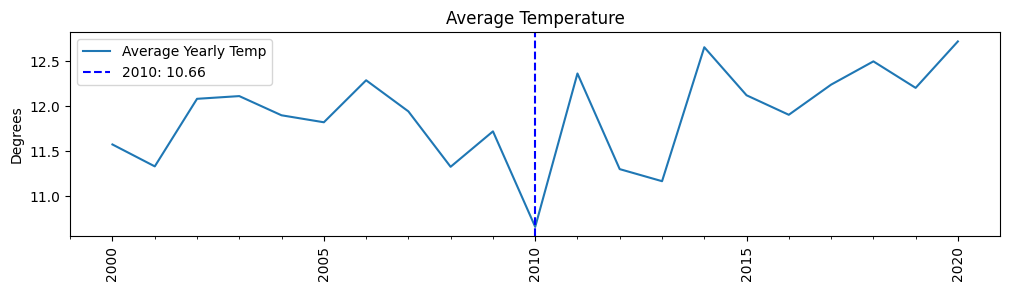

In [43]:
# Resample mean_temp to Yearly frequency using .mean()
yearly_temp = df_cleaned['mean_temp'].resample('YS').mean()

# Filter for 2000-2020
temp_2000_2020 = yearly_temp.loc['2000':'2020']

# Find coolest year and its value
min_val = temp_2000_2020.min()
min_year = temp_2000_2020.idxmax() # Placeholder logic to get index
min_year = temp_2000_2020.idxmin()

# Create wide figure
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(temp_2000_2020.index, temp_2000_2020.values, label='Average Yearly Temp')

# Add vertical line for lowest mean temp
label_text = f"{min_year.strftime('%Y')}: {min_val:.2f}"
ax.axvline(min_year, color='blue', linestyle='--', label=label_text)

# Titles and Labels
ax.set_title('Average Temperature')
ax.set_ylabel('Degrees')

# Major Ticks: Every 5 years, 4-digit labels, 90-degree rotation
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Minor Ticks: Every 1 year
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

# Rotate labels
plt.setp(ax.get_xticklabels(), rotation=90)
fig.autofmt_xdate(rotation=90, ha='center')

ax.legend()
plt.show()